<a href="https://colab.research.google.com/github/nouramar228-cyber/Time-Series-Analysis/blob/main/(Core)_Preparing_Time_Series_from_Wide_Form_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Part 1: Preparing Time Series from Wide-Form Data

### Import libraries

In [73]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import matplotlib.ticker as mticks

### Load dataset

In [74]:
fpath = "/content/drive/MyDrive/AXSOSACADEMY/AXSOSACADEMY/03-DataEnrichment/Week09/Data/City_zhvi_uc_sfrcondo_tier_0.33_0.67_sm_sa_month.csv"
df = pd.read_csv(fpath)
df.head()

,RegionID,SizeRank,RegionName,RegionType,StateName,State,Metro,CountyName,2000-01-31,2000-02-29,...,2021-12-31,2022-01-31,2022-02-28,2022-03-31,2022-04-30,2022-05-31,2022-06-30,2022-07-31,2022-08-31,2022-09-30
0,6181,0,New York,city,NY,NY,"New York-Newark-Jersey City, NY-NJ-PA",Queens County,253690.0,255517.0,...,741586.0,745686.0,750578.0,756734.0,762321.0,768797.0,773944.0,777692.0,779960.0,781622.0
1,12447,1,Los Angeles,city,CA,CA,"Los Angeles-Long Beach-Anaheim, CA",Los Angeles County,234181.0,234401.0,...,924019.0,928991.0,937936.0,953874.0,973168.0,990391.0,992337.0,992630.0,978196.0,966595.0
2,39051,2,Houston,city,TX,TX,"Houston-The Woodlands-Sugar Land, TX",Harris County,109068.0,109079.0,...,245783.0,248718.0,252080.0,256435.0,261101.0,265558.0,268901.0,271059.0,272400.0,272639.0
3,17426,3,Chicago,city,IL,IL,"Chicago-Naperville-Elgin, IL-IN-WI",Cook County,166139.0,166536.0,...,302821.0,305104.0,306404.0,308303.0,309649.0,312487.0,314663.0,315910.0,315587.0,315429.0
4,6915,4,San Antonio,city,TX,TX,"San Antonio-New Braunfels, TX",Bexar County,114794.0,114975.0,...,269323.0,274032.0,278464.0,284127.0,289739.0,294776.0,297727.0,298796.0,299124.0,298951.0


In [75]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22467 entries, 0 to 22466
Columns: 281 entries, RegionID to 2022-09-30
dtypes: float64(273), int64(2), object(6)
memory usage: 48.2+ MB


In [76]:
# ilter the Four Largest Cities
largest_cities = df[df['SizeRank'].isin([0,1,2,3])].copy()
largest_cities[['RegionName','StateName','SizeRank']]

,RegionName,StateName,SizeRank
0,New York,NY,0
1,Los Angeles,CA,1
2,Houston,TX,2
3,Chicago,IL,3


In [77]:
# Convert the Data from Wide Form to Long Form
id_cols = [
    'RegionID',
    'SizeRank',
    'RegionName',
    'RegionType',
    'StateName',
    'State',
    'Metro',
    'CountyName'
]

In [78]:
melted = pd.melt(
    largest_cities,
    id_vars=id_cols,
    var_name='Date',
    value_name='HomeValue'
)

melted.head()

,RegionID,SizeRank,RegionName,RegionType,StateName,State,Metro,CountyName,Date,HomeValue
0,6181,0,New York,city,NY,NY,"New York-Newark-Jersey City, NY-NJ-PA",Queens County,2000-01-31,253690.0
1,12447,1,Los Angeles,city,CA,CA,"Los Angeles-Long Beach-Anaheim, CA",Los Angeles County,2000-01-31,234181.0
2,39051,2,Houston,city,TX,TX,"Houston-The Woodlands-Sugar Land, TX",Harris County,2000-01-31,109068.0
3,17426,3,Chicago,city,IL,IL,"Chicago-Naperville-Elgin, IL-IN-WI",Cook County,2000-01-31,166139.0
4,6181,0,New York,city,NY,NY,"New York-Newark-Jersey City, NY-NJ-PA",Queens County,2000-02-29,255517.0


In [79]:
# Convert the Date Column to Datetime
melted['Date'] = pd.to_datetime(melted['Date'])
melted.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1092 entries, 0 to 1091
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   RegionID    1092 non-null   int64         
 1   SizeRank    1092 non-null   int64         
 2   RegionName  1092 non-null   object        
 3   RegionType  1092 non-null   object        
 4   StateName   1092 non-null   object        
 5   State       1092 non-null   object        
 6   Metro       1092 non-null   object        
 7   CountyName  1092 non-null   object        
 8   Date        1092 non-null   datetime64[ns]
 9   HomeValue   1087 non-null   float64       
dtypes: datetime64[ns](1), float64(1), int64(2), object(6)
memory usage: 85.4+ KB


In [80]:
# Set the Datetime Index
melted = melted.set_index('Date')
melted.head()

,RegionID,SizeRank,RegionName,RegionType,StateName,State,Metro,CountyName,HomeValue
Date,,,,,,,,,
2000-01-31,6181,0,New York,city,NY,NY,"New York-Newark-Jersey City, NY-NJ-PA",Queens County,253690.0
2000-01-31,12447,1,Los Angeles,city,CA,CA,"Los Angeles-Long Beach-Anaheim, CA",Los Angeles County,234181.0
2000-01-31,39051,2,Houston,city,TX,TX,"Houston-The Woodlands-Sugar Land, TX",Harris County,109068.0
2000-01-31,17426,3,Chicago,city,IL,IL,"Chicago-Naperville-Elgin, IL-IN-WI",Cook County,166139.0
2000-02-29,6181,0,New York,city,NY,NY,"New York-Newark-Jersey City, NY-NJ-PA",Queens County,255517.0


In [94]:
df_ts = melted.groupby('RegionName')[['HomeValue']].resample('MS').mean()
df_ts

HomeValue
RegionName Date                 
Chicago    2000-01-01   166139.0
           2000-02-01   166536.0
           2000-03-01   167368.0
           2000-04-01   168826.0
           2000-05-01   170499.0
...                          ...
New York   2022-05-01   768797.0
           2022-06-01   773944.0
           2022-07-01   777692.0
           2022-08-01   779960.0
           2022-09-01   781622.0

[1092 rows x 1 columns]

In [85]:
plot_df = df_ts.copy()

unstacked = plot_df.unstack(level=0)

unstacked.head()

HomeValue                                
RegionName   Chicago   Houston Los Angeles  New York
Date                                                
2000-01-01  166139.0  109068.0    234181.0  253690.0
2000-02-01  166536.0  109079.0    234401.0  255517.0
2000-03-01  167368.0  108878.0    235513.0  257207.0
2000-04-01  168826.0  108881.0    237589.0  260310.0
2000-05-01  170499.0  108834.0    240113.0  263204.0

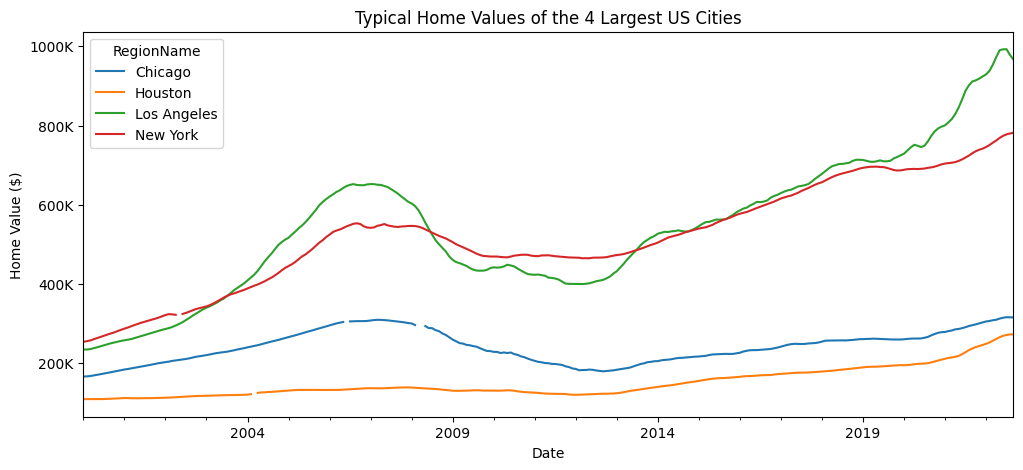

In [86]:
from matplotlib.ticker import FuncFormatter

fig, ax = plt.subplots(figsize=(12,5))

unstacked['HomeValue'].plot(ax=ax)

ax.set_title('Typical Home Values of the 4 Largest US Cities')
ax.set_xlabel('Date')
ax.set_ylabel('Home Value ($)')

formatter = FuncFormatter(lambda x, pos: f'{x/1000:.0f}K')
ax.yaxis.set_major_formatter(formatter)

plt.show()

## Question 1
* Which city had the highest typical home value at the end of 2008?

* Which city had the lowest typical home value at the end of 2008?

In [87]:
dec_2008 = unstacked['HomeValue'].loc['2008-12'].iloc[-1]

dec_2008

,2008-12-01
RegionName,
Chicago,265306.0
Houston,131283.0
Los Angeles,469294.0
New York,510309.0


In [97]:
highest_city = dec_2008.idxmax()
highest_value = dec_2008.max()

print(f"Highest Home Value at the end of 2008: {highest_city} (${highest_value:,.0f})")


Highest Home Value at the end of 2008: New York ($510,309)


In [96]:
lowest_city = dec_2008.idxmin()
lowest_value = dec_2008.min()

print(f"Lowest Home Value at the end of 2008: {lowest_city} (${lowest_value:,.0f})")

Lowest Home Value at the end of 2008: Houston ($131,283)


## Question 2
How much did home values change from November 2008 to December 2008?

In [93]:
nov_2008 = unstacked['HomeValue'].loc['2008-11'].iloc[-1]

dec_2008 = unstacked['HomeValue'].loc['2008-12'].iloc[-1]

change = dec_2008 - nov_2008

change

,0
RegionName,
Chicago,-5753.0
Houston,-964.0
Los Angeles,-12611.0
New York,-4458.0
